# PMS/PMDD Reddit Discourse Analysis
### How do people with PMS/PMDD describe their biggest recurring luteal-phase problems, coping attempts, and what kind of help feels usable instead of burdensome?

**Pipeline overview:**
1. Load & inspect data
2. Frequency analysis — validate coding-sheet categories
3. Token-level word frequency — surface unexpected vocabulary
4. Theme clustering — TF-IDF + KMeans
5. Tone scoring — VADER sentiment
6. Export annotated CSV for qualitative follow-up

---
## 0. Imports

In [1]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_colwidth", 120)

print("All imports OK")

All imports OK


---
## Step 1 — Load & inspect the corpus

Confirm row count, column shape, missing values, and the look of a typical row before any analysis.

In [2]:
df = pd.read_csv("../data/raw/posts.csv")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print("\nMissing values per column:")
print(df.isnull().sum())

Shape: 507 rows × 7 columns

Columns: ['subreddit', 'title', 'body', 'score', 'num_comments', 'url', 'search_term']

Missing values per column:
subreddit        0
title            0
body            34
score            0
num_comments     0
url              0
search_term      0
dtype: int64


In [ ]:
# Preview the first 3 rows — read the actual text to ground yourself in the data
df.head(3)

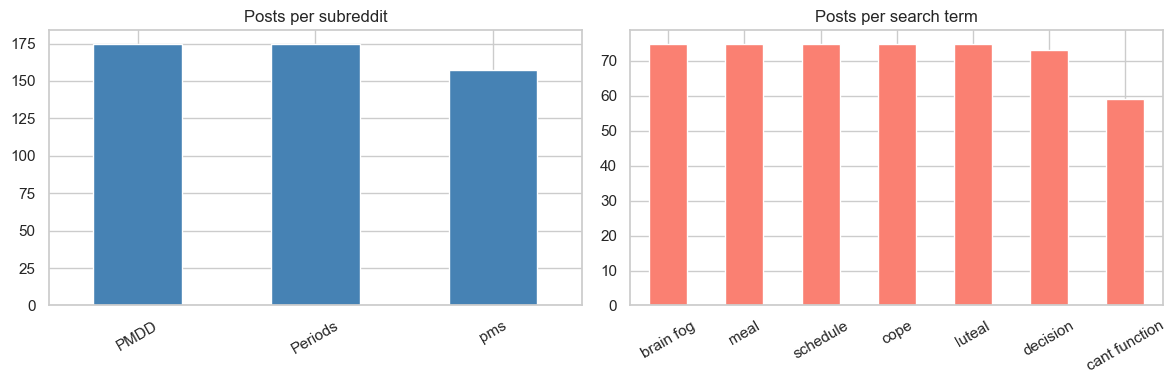

In [4]:
# How many posts per subreddit?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["subreddit"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Posts per subreddit")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

df["search_term"].value_counts().plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Posts per search term")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

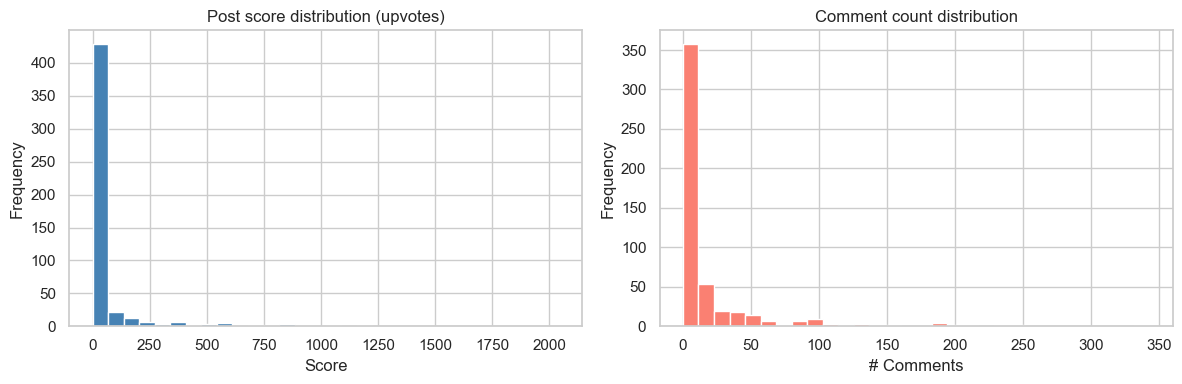

        score  num_comments
count   507.0         507.0
mean     79.8          19.1
std     242.9          38.8
min       0.0           0.0
25%       2.0           2.0
50%       7.0           5.0
75%      24.0          15.0
max    2043.0         343.0


In [5]:
# Score and engagement distributions — tells us which posts resonated most
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["score"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Post score distribution (upvotes)")
axes[0].set_xlabel("Score")

df["num_comments"].plot(kind="hist", bins=30, ax=axes[1], color="salmon")
axes[1].set_title("Comment count distribution")
axes[1].set_xlabel("# Comments")

plt.tight_layout()
plt.show()

print(df[["score", "num_comments"]].describe().round(1))

---
## Step 2 — Frequency analysis: validate coding-sheet categories

Test whether the keywords from the coding sheet (`pain_point`, `coping`, `unmet_need`, `app_signal`) actually appear in the corpus. A keyword with zero hits means either the community uses different vocabulary or the concept is genuinely absent — both are findings worth recording.

In [6]:
# Combine title + body into a single lowercase text column
# We do this so one search catches both the headline and the post body
df["text"] = df["title"].fillna("") + " " + df["body"].fillna("")
df["text"] = df["text"].str.lower()

print("Sample text (first post):")
print(df["text"].iloc[0][:300], "...")

Sample text (first post):
don't make decisions in luteal lol friendly reminder to not make any major life decisions while in luteal. i've quit jobs, made appointments to see plastic surgeons, contemplated leaving my partner, the list goes on. 

every questionable decision ive made can be followed back to a pmdd episode 😭 ...


In [7]:
# ── Coding-sheet keyword lists ──────────────────────────────────────────────
# Edit these lists to match what you observe in your posts.
# Add synonyms you noticed while reading (e.g. "brain fog" → also "foggy")
#
# Lists were iteratively expanded after Step 3 surfaced new vocabulary.
CATEGORIES = {
    "pain_point": [
        # original
        "anxiety", "rage", "anger", "irritable", "irritability",
        "cry", "crying", "depression", "depressed", "mood", "mood swing",
        "brain fog", "foggy", "fatigue", "exhausted", "insomnia", "sleep",
        "bloat", "cramp", "pain", "headache", "migraine",
        "suicidal", "self harm", "hopeless", "overwhelm",
        # added from Step 3
        "cycle", "symptoms", "luteal", "dissociation",
        "panic attack", "mood swings", "nausea", "palpitation",
        "cant function",
    ],
    "coping": [
        # original
        "ssri", "prozac", "zoloft", "lexapro", "antidepressant",
        "birth control", "iud", "pill", "progesterone", "hormone",
        "therapy", "therapist", "cbt",
        "exercise", "yoga", "walk", "diet", "magnesium", "vitamin",
        "meditation", "journal", "tracking", "app",
        "alcohol", "weed", "cannabis",
        # added from Step 3
        "seed cycling", "inositol", "vitex", "spearmint",
        "omega", "heating pad", "rest", "nap",
    ],
    "unmet_need": [
        # original (kept high-performing ones; removed "if only", "want help",
        # "still struggle" which each had 0 hits)
        "wish", "nobody", "no one", "dismissed", "don't understand",
        "doesn't help", "didn't help", "not enough",
        "need", "looking for", "does anyone", "has anyone",
        # added from Step 3
        "nothing works", "tried everything", "no cure",
        "feel normal", "at a loss", "exhausted options",
    ],
    "app_signal": [
        # unchanged — existing terms performed well
        "app", "track", "tracker", "reminder", "calendar", "log", "logging",
        "clue", "flo", "notion", "spreadsheet", "chart"
    ]
}


def keyword_freq(df, keywords):
    """Count how many posts contain each keyword (word-boundary match)."""
    return {
        kw: int(df["text"].str.contains(r"\b" + re.escape(kw) + r"\b", regex=True).sum())
        for kw in keywords
    }


# Build a tidy DataFrame: category | keyword | count
rows = []
for category, keywords in CATEGORIES.items():
    freq = keyword_freq(df, keywords)
    for kw, count in freq.items():
        rows.append({"category": category, "keyword": kw, "count": count})

freq_df = pd.DataFrame(rows).sort_values(["category", "count"], ascending=[True, False])
print(freq_df.to_string(index=False))

  category           keyword  count
app_signal             track     11
app_signal               app     10
app_signal          calendar      7
app_signal          reminder      5
app_signal               flo      5
app_signal           tracker      1
app_signal           logging      1
app_signal              clue      1
app_signal            notion      1
app_signal       spreadsheet      1
app_signal             chart      1
app_signal               log      0
    coping     birth control     49
    coping          exercise     33
    coping              diet     33
    coping              rest     27
    coping           hormone     20
    coping              pill     19
    coping      progesterone     18
    coping              walk     16
    coping           vitamin     13
    coping               iud     11
    coping         therapist     11
    coping         magnesium     10
    coping               app     10
    coping           therapy      9
    coping            zoloft

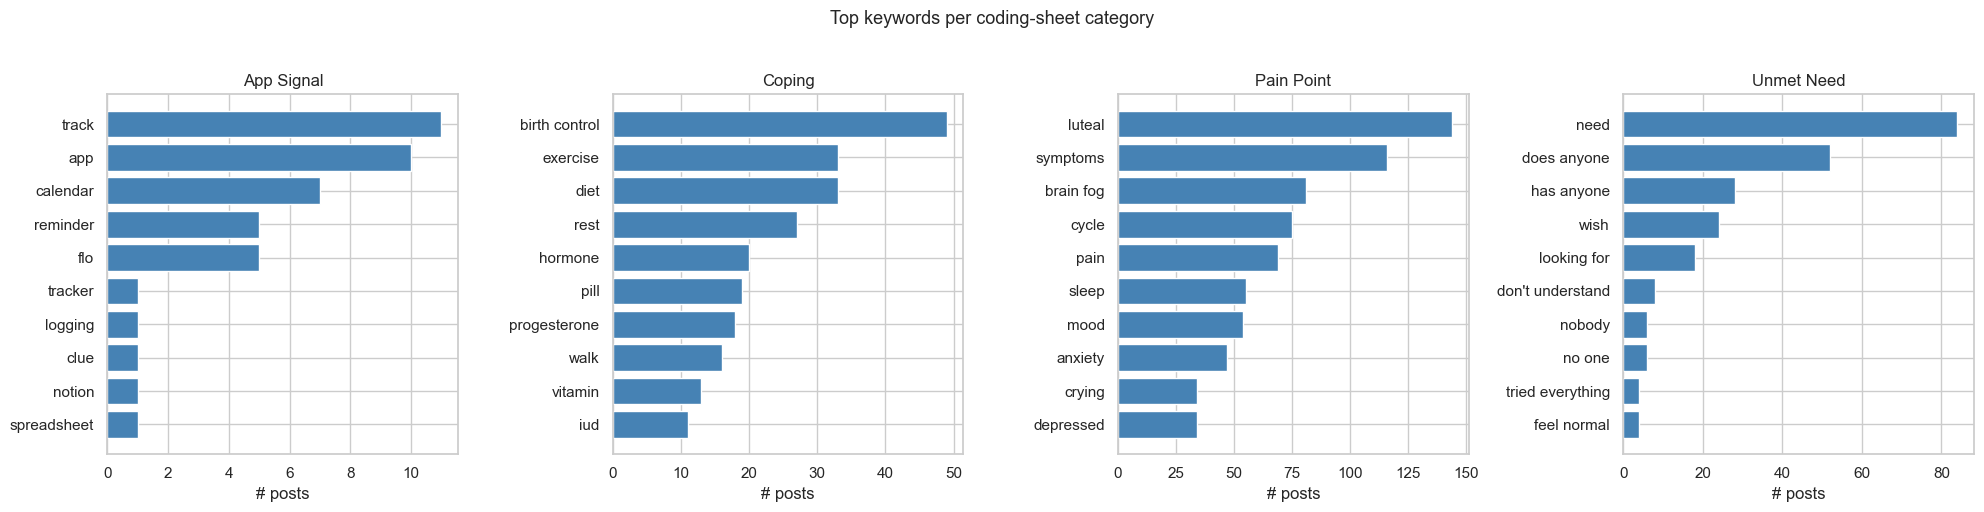

In [8]:
# Visualize: top-10 keywords per category
categories = freq_df["category"].unique()
fig, axes = plt.subplots(1, len(categories), figsize=(5 * len(categories), 5))

for ax, cat in zip(axes, categories):
    subset = freq_df[freq_df["category"] == cat].nlargest(10, "count")
    ax.barh(subset["keyword"], subset["count"], color="steelblue")
    ax.invert_yaxis()
    ax.set_title(cat.replace("_", " ").title())
    ax.set_xlabel("# posts")

plt.suptitle("Top keywords per coding-sheet category", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Reading the chart:** Keywords with 0 or near-0 counts either aren't used in this community (they may use different terms) or the concept is genuinely rare. Update your keyword lists accordingly before moving on.

---
## Step 3 — Token-level frequency: surface unexpected vocabulary

Step 2 only finds words you already thought of. This step surfaces what the community itself uses most, with no a-priori list. Bigrams (two-word phrases) are included because community-specific terms — "luteal brain," "PMDD rage," "luteal goblin mode" — carry more signal as phrases than as single words.

In [9]:
# A minimal English stopword list.
# If you install nltk you can replace this with: nltk.corpus.stopwords.words("english")
STOPWORDS = {
    "i", "me", "my", "myself", "we", "our", "you", "your", "he", "she", "it",
    "they", "them", "what", "which", "who", "this", "that", "these", "those",
    "am", "is", "are", "was", "were", "be", "been", "being", "have", "has",
    "had", "do", "does", "did", "will", "would", "could", "should", "may",
    "might", "can", "a", "an", "the", "and", "but", "or", "nor", "so", "yet",
    "for", "of", "in", "on", "at", "by", "to", "from", "up", "about", "into",
    "with", "as", "if", "then", "than", "when", "where", "not", "no", "just",
    "like", "get", "got", "also", "even", "really", "very", "much", "more",
    "know", "think", "feel", "want", "need", "time", "one", "all", "any",
    "its", "re", "ve", "ll", "don", "doesn", "didn", "won", "isn", "aren",
    "wasn", "weren", "hasn", "hadn", "couldn", "wouldn", "shouldn", "amp"
}


def tokenize(text):
    """Lowercase, keep only alphabetic tokens of length >= 3, remove stopwords."""
    tokens = re.findall(r"\b[a-z]{3,}\b", str(text).lower())
    return [t for t in tokens if t not in STOPWORDS]


all_tokens = [token for text in df["text"] for token in tokenize(text)]
top_words = Counter(all_tokens).most_common(50)

top_words_df = pd.DataFrame(top_words, columns=["word", "count"])
print(top_words_df.to_string(index=False))

     word  count
   period    626
      how    391
  because    332
     days    306
      out    304
   luteal    299
   during    276
      day    275
      pms    261
      now    249
   before    241
     work    224
     week    219
 symptoms    217
    month    216
    phase    211
     some    209
     take    205
     help    204
     pmdd    201
   anyone    201
    every    198
     make    185
    brain    179
     life    175
    after    171
  periods    170
   things    161
      bad    160
     only    155
     pain    152
     else    152
    other    147
     last    146
    there    143
 anything    141
      eat    129
      way    128
   normal    126
      too    124
   having    124
     over    123
  getting    122
     back    121
    cycle    121
      fog    121
something    120
      her    119
      few    119
    going    118


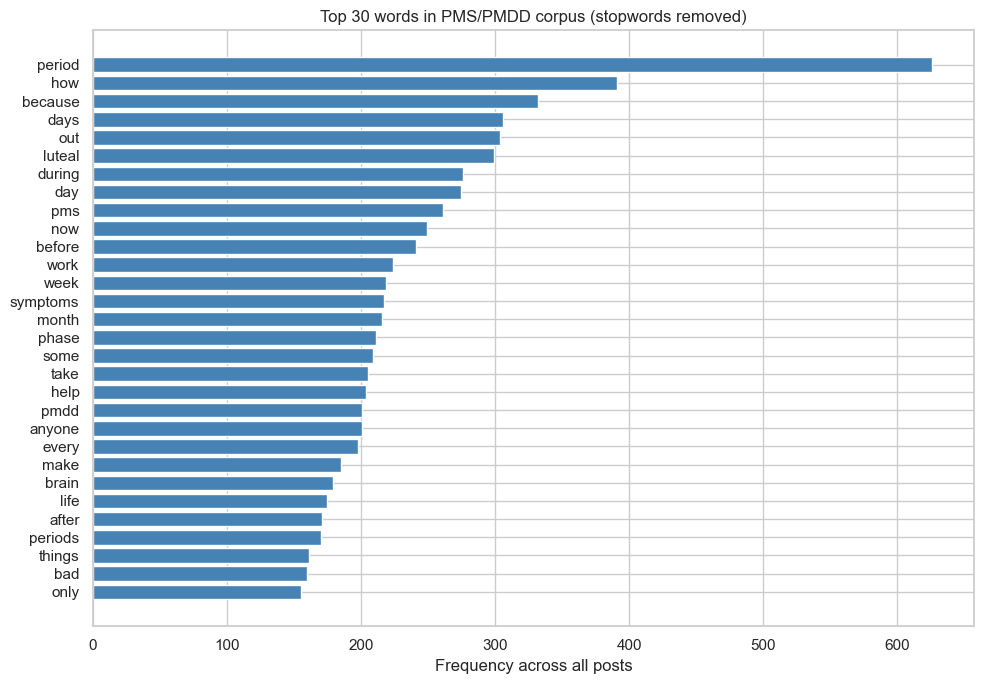

In [10]:
# Bar chart of top 30 words
top30 = top_words_df.head(30)

plt.figure(figsize=(10, 7))
plt.barh(top30["word"], top30["count"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Frequency across all posts")
plt.title("Top 30 words in PMS/PMDD corpus (stopwords removed)")
plt.tight_layout()
plt.show()

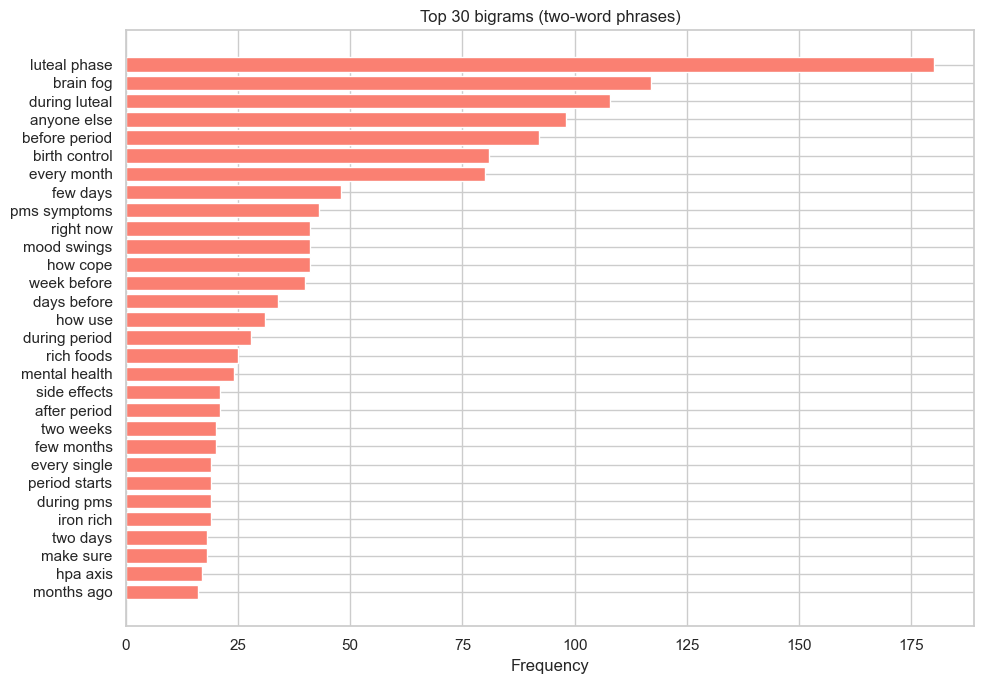

In [11]:
# Bigrams — two-word phrases often carry more meaning than single words
# e.g. "brain fog" vs "brain" alone

def bigrams(tokens):
    return [(tokens[i], tokens[i+1]) for i in range(len(tokens) - 1)]

all_bigrams = []
for text in df["text"]:
    tokens = tokenize(text)
    all_bigrams.extend(bigrams(tokens))

top_bigrams = Counter(all_bigrams).most_common(30)
bigram_df = pd.DataFrame(
    [(" ".join(bg), count) for bg, count in top_bigrams],
    columns=["bigram", "count"]
)

plt.figure(figsize=(10, 7))
plt.barh(bigram_df["bigram"], bigram_df["count"], color="salmon")
plt.gca().invert_yaxis()
plt.xlabel("Frequency")
plt.title("Top 30 bigrams (two-word phrases)")
plt.tight_layout()
plt.show()

In [12]:
# ── Step 3.5 — Gap Finder: which top words/bigrams are NOT in CATEGORIES? ────
#
# PURPOSE: Automate the cross-reference between Step 3's frequency output
# and Step 2's keyword lists. Instead of eyeballing two long lists manually,
# this cell prints only the words that are both (a) high-frequency and
# (b) not yet covered by any coding-sheet category.
# Use the output to decide what to add to CATEGORIES in Step 2, then re-run.

all_keywords_flat = {kw for kws in CATEGORIES.values() for kw in kws}

# Single words: top 50 that aren't in any category
missing_singles = [(w, c) for w, c in Counter(all_tokens).most_common(50)
                   if w not in all_keywords_flat]

# Bigrams: top 30 that aren't in any category
top30_bigrams = [(' '.join(bg), c) for bg, c in Counter(all_bigrams).most_common(30)]
missing_bigrams = [(bg, c) for bg, c in top30_bigrams if bg not in all_keywords_flat]

print('Top single words NOT covered by any category:')
print(f'{"word":<20} {"count":>6}')
print('-' * 28)
for word, count in missing_singles:
    print(f'  {word:<18} {count:>6}')

print('\nTop bigrams NOT covered by any category:')
print(f'{"bigram":<30} {"count":>6}')
print('-' * 38)
for bigram, count in missing_bigrams:
    print(f'  {bigram:<28} {count:>6}')

print('\n→ Review these and add meaningful ones to CATEGORIES in Step 2, then re-run cells 10–11.')


Top single words NOT covered by any category:
word                  count
----------------------------
  period                626
  how                   391
  because               332
  days                  306
  out                   304
  during                276
  day                   275
  pms                   261
  now                   249
  before                241
  work                  224
  week                  219
  month                 216
  phase                 211
  some                  209
  take                  205
  help                  204
  pmdd                  201
  anyone                201
  every                 198
  make                  185
  brain                 179
  life                  175
  after                 171
  periods               170
  things                161
  bad                   160
  only                  155
  else                  152
  other                 147
  last                  146
  there                 143
 

**What to look for:** Bigrams like `"luteal phase"`, `"birth control"`, `"mood swings"` confirm expected themes. Surprising bigrams you didn't have in your coding sheet (Step 2) should be added to the keyword lists and re-run.

---
## Step 4 — Theme clustering: TF-IDF + KMeans

Steps 2–3 are keyword-driven. This step groups posts by similarity into themes without predefined categories. `k` was chosen from the elbow plot below.

In [13]:
# TF-IDF vectorization
# max_features=300   → only keep the 300 most informative words (keeps it fast)
# ngram_range=(1,2)  → include single words AND two-word phrases
# min_df=2           → ignore words that appear in only 1 post (likely typos)

vectorizer = TfidfVectorizer(
    max_features=300,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X = vectorizer.fit_transform(df["text"])   # sparse matrix: rows=posts, cols=words
print(f"Matrix shape: {X.shape}  (posts × features)")

Matrix shape: (507, 300)  (posts × features)


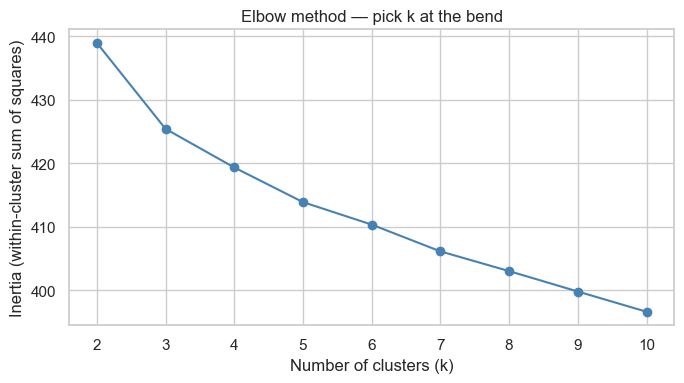

In [14]:
# ── Elbow method: helps choose the right number of clusters (k) ──────────────
# For each k, KMeans measures how tightly packed each cluster is (inertia).
# The "elbow" — where the curve bends and gains slow down — is a good k.

inertias = []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_RANGE), inertias, marker="o", color="steelblue")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow method — pick k at the bend")
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

In [15]:
# ── Run KMeans with chosen k ─────────────────────────────────────────────────
# Change K below based on the elbow plot above.

K = 3

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

print("Posts per cluster:")
print(df["cluster"].value_counts().sort_index())

Posts per cluster:
cluster
0     86
1     61
2    360
Name: count, dtype: int64


In [16]:
# ── What is each cluster about? ───────────────────────────────────────────────
# For each cluster, print the top 12 TF-IDF terms.
# These are the words that best define each group — your "theme label".

feature_names = vectorizer.get_feature_names_out()

print("Top 12 terms per cluster:\n")
for i in range(K):
    top_idx = np.argsort(kmeans.cluster_centers_[i])[::-1][:12]
    top_terms = [feature_names[j] for j in top_idx]
    print(f"  Cluster {i}: {', '.join(top_terms)}")

Top 12 terms per cluster:

  Cluster 0: luteal, phase, luteal phase, like, cycle, feel, just, does, life, decisions, month, day
  Cluster 1: brain, fog, brain fog, period, does, feel, like, work, pms, just, days, help
  Cluster 2: period, like, just, pms, feel, days, time, ve, don, day, week, pmdd


In [ ]:
# ── Read representative posts from each cluster ───────────────────────────────
# The terms tell you WHAT the cluster is about; the titles confirm it.
# Reading 3–5 actual titles per cluster lets you assign a human-readable name.

for i in range(K):
    print(f"\n{'='*60}")
    print(f" Cluster {i} — sample titles")
    print(f"{'='*60}")
    sample = df[df["cluster"] == i][["title", "score", "subreddit"]].head(5)
    for _, row in sample.iterrows():
        print(f"  [{row['subreddit']}] (score {row['score']}) {row['title']}")

In [18]:
CLUSTER_NAMES = {
    0: "Luteal Phase Decision-Making: Advice & Warnings",
    1: "Cognitive Symptoms: Brain Fog, Fatigue & Dissociation",
    2: "Personal PMDD Narratives & Life Decisions",
}

df["cluster_name"] = df["cluster"].map(CLUSTER_NAMES)
print(df["cluster_name"].value_counts())

cluster_name
Personal PMDD Narratives & Life Decisions                360
Luteal Phase Decision-Making: Advice & Warnings           86
Cognitive Symptoms: Brain Fog, Fatigue & Dissociation     61
Name: count, dtype: int64


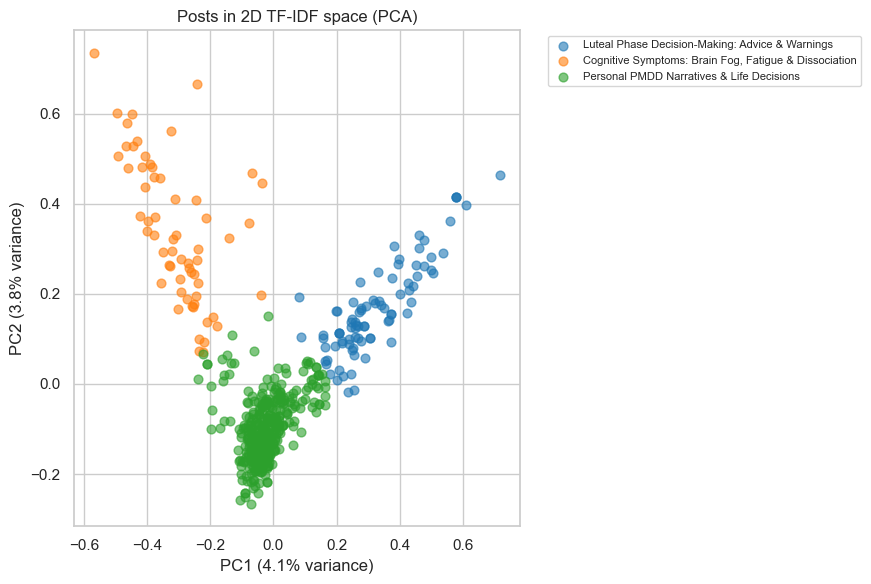

In [19]:
# ── 2D visualization of clusters using PCA ───────────────────────────────────
# PCA (Principal Component Analysis) compresses 300 TF-IDF dimensions
# down to 2 so we can plot them. Nearby dots = similar posts.
# Well-separated blobs = clean clusters; overlapping blobs = fuzzy boundaries.

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X.toarray())

plt.figure(figsize=(9, 6))
palette = sns.color_palette("tab10", K)

for i in range(K):
    mask = df["cluster"] == i
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=CLUSTER_NAMES[i], alpha=0.6, s=40, color=palette[i])

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Posts in 2D TF-IDF space (PCA)")
plt.tight_layout()
plt.show()

---
## Step 5 — Tone scoring (VADER)

Adding sentiment lets us ask which pain points generate the most distress, which coping strategies generate hope vs. frustration, and which subreddits skew supportive vs. venting. VADER's compound score runs from −1 (most negative) to +1 (most positive).

In [20]:
sia = SentimentIntensityAnalyzer()

# Score every post; compound is the single summary score
df["sentiment"] = df["text"].apply(lambda t: sia.polarity_scores(t)["compound"])

# Quick summary
print(df["sentiment"].describe().round(3))
print(f"\nNegative (<−0.05): {(df['sentiment'] < -0.05).sum()} posts")
print(f"Neutral  (−0.05–0.05): {(df['sentiment'].between(-0.05, 0.05)).sum()} posts")
print(f"Positive (>0.05): {(df['sentiment'] > 0.05).sum()} posts")

count    507.000
mean      -0.127
std        0.769
min       -0.998
25%       -0.879
50%       -0.402
75%        0.739
max        1.000
Name: sentiment, dtype: float64

Negative (<−0.05): 282 posts
Neutral  (−0.05–0.05): 17 posts
Positive (>0.05): 208 posts


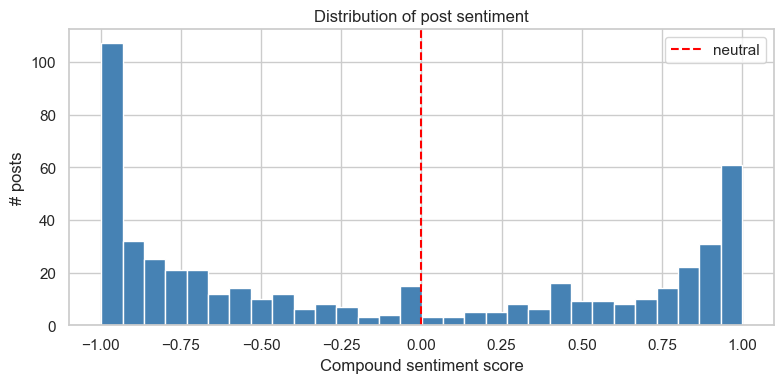

In [21]:
# Sentiment distribution
plt.figure(figsize=(8, 4))
plt.hist(df["sentiment"], bins=30, color="steelblue", edgecolor="white")
plt.axvline(0, color="red", linestyle="--", label="neutral")
plt.xlabel("Compound sentiment score")
plt.ylabel("# posts")
plt.title("Distribution of post sentiment")
plt.legend()
plt.tight_layout()
plt.show()

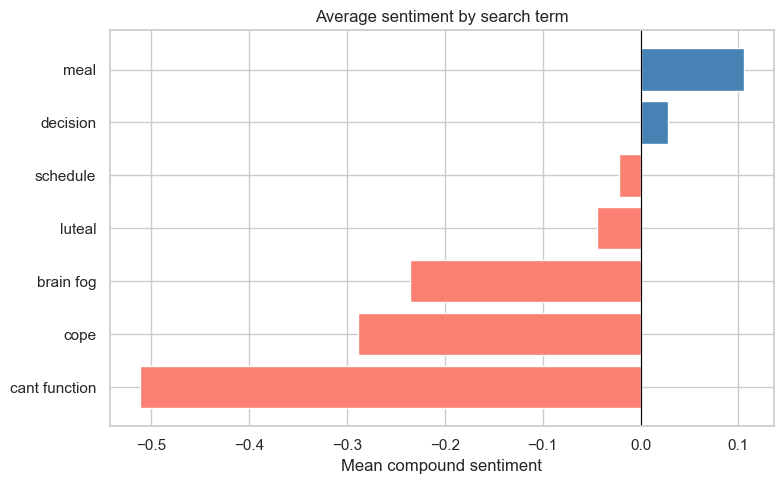

In [22]:
# Average sentiment by search term — which topics generate most distress?
sent_by_term = df.groupby("search_term")["sentiment"].mean().sort_values()

plt.figure(figsize=(8, 5))
colors = ["salmon" if v < 0 else "steelblue" for v in sent_by_term]
plt.barh(sent_by_term.index, sent_by_term.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Mean compound sentiment")
plt.title("Average sentiment by search term")
plt.tight_layout()
plt.show()

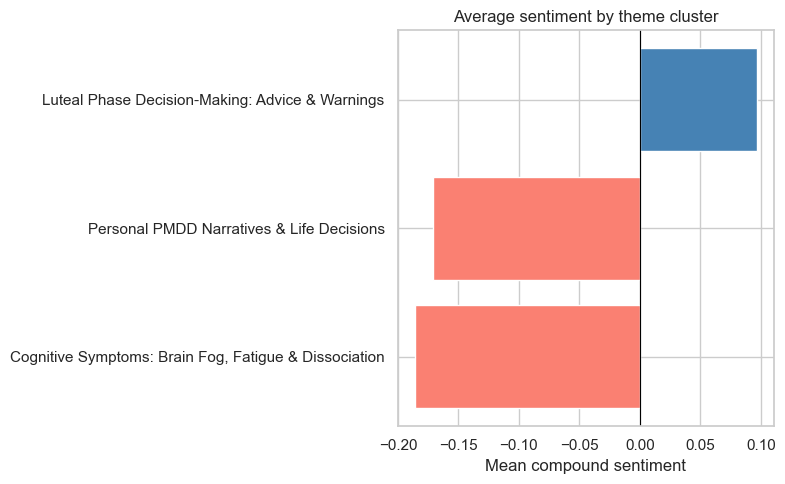

In [23]:
# Average sentiment by cluster — which themes are most distressed?
sent_by_cluster = df.groupby("cluster_name")["sentiment"].mean().sort_values()

plt.figure(figsize=(8, 5))
colors = ["salmon" if v < 0 else "steelblue" for v in sent_by_cluster]
plt.barh(sent_by_cluster.index, sent_by_cluster.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Mean compound sentiment")
plt.title("Average sentiment by theme cluster")
plt.tight_layout()
plt.show()

In [24]:
# Most negative posts — candidates for qualitative deep-read
print("10 most negative posts:\n")
cols = ["subreddit", "search_term", "sentiment", "cluster_name"]
print(df.nsmallest(10, "sentiment")[cols].to_string(index=False))

10 most negative posts:

subreddit   search_term  sentiment                              cluster_name
     PMDD      decision    -0.9983 Personal PMDD Narratives & Life Decisions
  Periods cant function    -0.9983 Personal PMDD Narratives & Life Decisions
     PMDD          cope    -0.9981 Personal PMDD Narratives & Life Decisions
      pms          cope    -0.9981 Personal PMDD Narratives & Life Decisions
  Periods cant function    -0.9980 Personal PMDD Narratives & Life Decisions
  Periods cant function    -0.9979 Personal PMDD Narratives & Life Decisions
      pms      schedule    -0.9960 Personal PMDD Narratives & Life Decisions
  Periods cant function    -0.9958 Personal PMDD Narratives & Life Decisions
     PMDD          cope    -0.9952 Personal PMDD Narratives & Life Decisions
     PMDD          cope    -0.9951 Personal PMDD Narratives & Life Decisions


In [25]:
# Most positive posts — coping success stories
print("10 most positive posts:\n")
print(df.nlargest(10, "sentiment")[cols].to_string(index=False))

10 most positive posts:

subreddit   search_term  sentiment                                    cluster_name
      pms          meal     0.9997 Luteal Phase Decision-Making: Advice & Warnings
      pms      schedule     0.9997 Luteal Phase Decision-Making: Advice & Warnings
      pms        luteal     0.9997 Luteal Phase Decision-Making: Advice & Warnings
  Periods          meal     0.9997       Personal PMDD Narratives & Life Decisions
     PMDD cant function     0.9992       Personal PMDD Narratives & Life Decisions
     PMDD      decision     0.9966       Personal PMDD Narratives & Life Decisions
      pms      schedule     0.9962       Personal PMDD Narratives & Life Decisions
     PMDD        luteal     0.9954 Luteal Phase Decision-Making: Advice & Warnings
  Periods      decision     0.9939       Personal PMDD Narratives & Life Decisions
      pms     brain fog     0.9926       Personal PMDD Narratives & Life Decisions


---
## Step 6 — Export Annotated CSV

Export the full dataset with all new columns (`cluster`, `cluster_name`, `sentiment`) added. This becomes the basis for qualitative coding in your next phase — you can open it in Excel/Google Sheets and manually annotate each row against your coding sheet.

In [26]:
# Add binary keyword flags to make manual coding easier
# Each flag column = 1 if any keyword in that category appears in the post

for category, keywords in CATEGORIES.items():
    pattern = "|".join([r"\b" + re.escape(kw) + r"\b" for kw in keywords])
    df[f"flag_{category}"] = df["text"].str.contains(pattern, regex=True).astype(int)

# Drop the combined text column (redundant now, and verbose in CSV)
export_cols = [
    "subreddit", "title", "body", "score", "num_comments", "url", "search_term",
    "cluster", "cluster_name", "sentiment",
    "flag_pain_point", "flag_coping", "flag_unmet_need", "flag_app_signal"
]

df[export_cols].to_csv("../data/raw/posts_annotated.csv", index=False)
print("Saved: ../data/raw/posts_annotated.csv")
print(f"Columns: {export_cols}")

Saved: ../data/raw/posts_annotated.csv
Columns: ['subreddit', 'title', 'body', 'score', 'num_comments', 'url', 'search_term', 'cluster', 'cluster_name', 'sentiment', 'flag_pain_point', 'flag_coping', 'flag_unmet_need', 'flag_app_signal']


In [27]:
# Final summary table: per cluster — post count, avg sentiment, flag rates
summary = df.groupby("cluster_name").agg(
    n_posts=("title", "count"),
    avg_sentiment=("sentiment", "mean"),
    pct_pain_point=("flag_pain_point", "mean"),
    pct_coping=("flag_coping", "mean"),
    pct_unmet_need=("flag_unmet_need", "mean"),
    pct_app_signal=("flag_app_signal", "mean"),
).round(3)

print(summary.to_string())

                                                       n_posts  avg_sentiment  pct_pain_point  pct_coping  pct_unmet_need  pct_app_signal
cluster_name                                                                                                                             
Cognitive Symptoms: Brain Fog, Fatigue & Dissociation       61         -0.186           1.000       0.197           0.344           0.033
Luteal Phase Decision-Making: Advice & Warnings             86          0.097           1.000       0.267           0.349           0.093
Personal PMDD Narratives & Life Decisions                  360         -0.171           0.736       0.431           0.417           0.067


## Step 7 — Qualitative Deep-Read

Filter to posts that are **high-engagement** (`score > 50`) AND **highly negative** (`sentiment < −0.5`).
These are the posts the community upvoted most while expressing real distress — the richest signal for understanding unmet needs.

Read each one and note:
- What specific problem are they describing?
- What have they already tried?
- What kind of help are they asking for or wishing existed?

In [28]:
# ── Step 7 — Qualitative Deep-Read ───────────────────────────────────────────
# High community engagement (score > 50) AND high distress (sentiment < -0.5).
# These are widely-shared, under-solved problems.

deep_read = pd.read_csv('../data/raw/posts_annotated.csv')

filtered = (
    deep_read
    .query('score > 50 and sentiment < -0.5')
    .sort_values('score', ascending=False)
    .reset_index(drop=True)
)

print(f'Posts matching criteria (score > 50, sentiment < -0.5): {len(filtered)}\n')
print(filtered[['subreddit', 'score', 'sentiment', 'cluster_name']].to_string(index=True))

Posts matching criteria (score > 50, sentiment < -0.5): 32

   subreddit  score  sentiment                                           cluster_name
0    Periods   1162    -0.9136        Luteal Phase Decision-Making: Advice & Warnings
1       PMDD    833    -0.8294              Personal PMDD Narratives & Life Decisions
2       PMDD    828    -0.5106        Luteal Phase Decision-Making: Advice & Warnings
3       PMDD    510    -0.7175              Personal PMDD Narratives & Life Decisions
4    Periods    434    -0.8176              Personal PMDD Narratives & Life Decisions
5       PMDD    366    -0.8860        Luteal Phase Decision-Making: Advice & Warnings
6       PMDD    352    -0.7622              Personal PMDD Narratives & Life Decisions
7       PMDD    273    -0.9919              Personal PMDD Narratives & Life Decisions
8    Periods    260    -0.9848              Personal PMDD Narratives & Life Decisions
9       PMDD    241    -0.7351  Cognitive Symptoms: Brain Fog, Fatigue & Dissoci

In [29]:
# Save the filtered set for follow-up qualitative reading.
# Bodies and URLs are intentionally NOT printed — they live in the gitignored
# data/raw/ source. The published artifact is the synthesis below (cell 40).

filtered.to_csv('../data/raw/deep_read_candidates.csv', index=False)
print(f'Saved {len(filtered)} candidates → ../data/raw/deep_read_candidates.csv')

Saved 32 candidates → ../data/raw/deep_read_candidates.csv


### Qualitative synthesis — deep-read posts

Patterns observed across the high-engagement, high-distress posts. Quotes are paraphrased; specific examples have been generalized to avoid reverse-searchability.

**Recurring pain patterns**

- **Cognitive shutdown is the dominant complaint, not mood.** Brain fog, inability to speak clearly, forgetting plans, losing executive function. Multiple posts describe this as the worst symptom because — unlike anxiety, depression, or rage — it can't be masked at work or in front of others.
- **Decision paralysis around ordinary tasks.** Scheduling appointments, making phone calls, planning meals — these become impossible. Several posts describe being unable to even initiate a routine call (hair appointment, doctor) because the user spirals into worst-case outcomes before dialing.
- **The crash → guilt → overcompensation loop.** Calling out of work, then feeling like a burden, then pushing harder once the window passes, then burning out. The cycle repeats monthly. Many posters describe feeling they're "letting down" partners, children, or coworkers.
- **Identity split.** Posters describe their luteal self as a separate, unwanted person inhabiting their body — and partners and family often treat it the same way. The framing of "this isn't me" is widespread.
- **Relationship erosion on a schedule.** Posts orbit the question of whether others "almost get divorced every month." One striking thread describes a partner secretly venting about the user's PMDD to an AI chatbot. The recurring complaint: luteal behavior damages trust, and there is no system to protect relationships from it.
- **Substance reliance as the only fast-acting tool.** THC is the most-mentioned. Users describe it as effective for acute spiral prevention but functionally disabling — they can't drive or work, and several explicitly name the bind of needing a substance they can't function on.

**What users have already tried (and why it fails)**

- **SSRIs (luteal-phase dosing).** Helps the emotional floor; doesn't touch brain fog or executive function. Posters describe being maxed out on dose and still unable to think clearly.
- **THC.** Effective for spiral prevention, creates functional dependency.
- **Spoon theory / task triage.** The single most positive coping report in the dataset comes from a poster who broke her day into the three tasks she had spoons for and got through. The intervention worked — but still required cognitive overhead to choose the three tasks.
- **Pushing through / masking.** Described in one striking exchange between a poster and her doctor as "less resilience than quiet survival." Functions until it doesn't; the fear of the mask slipping at work is itself a recurring stressor.
- **Lifestyle changes (diet, exercise, sleep hygiene).** The science is widely understood in the community (HPA-axis explanations get upvoted), but posters consistently note that on their worst days the advice is correct yet unactionable — they cannot do the thing that would help.
- **Existing period and mood tracking apps.** Notably absent from coping reports. Across the qualitative set, no poster names a current app as having helped them through a luteal episode.

**What kind of help users are asking for**

- **Concrete action over education.** The most common ask is "what do you DO?" — not "what is PMDD." Posters already know the diagnosis; they want a specific next move.
- **Low-cognitive-cost interventions.** The spoon-theory case is the proof: the user didn't need a plan, she needed someone to narrow the day to three things.
- **Permission to scale back without guilt.** Many posts orbit the desire to cancel, postpone, or rest — blocked by guilt. Users want external validation that pulling back is the right move, not a failure.
- **A buffer between the luteal self and the people who depend on them.** Partner posts, doctor posts, and work posts share this shape: the user wants something that protects relationships and obligations from a self she can't fully control during the window.
- **Solidarity first, solutions second.** Almost every post opens with "does anyone else?" The unmet need is partly functional and partly the experience of being uniquely broken. Acknowledgment matters before any intervention does.

---
## Step 8 — App-Signal Analysis

Filter to posts where `flag_app_signal == 1` — posts that mention apps, trackers, calendars, or logging tools.

Read these to answer:
- What are people tracking, and why?
- Which tools do they name, and how do they feel about them?
- What do they wish the tools did that they don't?

This directly informs CLARVUE's design.

In [ ]:
# ── Step 8 — App-Signal Analysis ─────────────────────────────────────────────
# Filter: any post mentioning an app, tracker, calendar, or logging tool.
# Also detects which specific keyword matched so you know what tool they named.

app_posts = (
    deep_read
    .query('flag_app_signal == 1')
    .sort_values('score', ascending=False)
    .reset_index(drop=True)
)

print(f'Posts mentioning app/tracker keywords: {len(app_posts)}\n')

# Show which specific keywords matched in each post
APP_KEYWORDS = ['app', 'track', 'tracker', 'reminder', 'calendar',
                'log', 'logging', 'clue', 'flo', 'notion', 'spreadsheet', 'chart']

def find_matched(row):
    text = (str(row['title']) + ' ' + str(row['body'])).lower()
    return ', '.join(kw for kw in APP_KEYWORDS if f' {kw} ' in f' {text} ')

app_posts['matched_keywords'] = app_posts.apply(find_matched, axis=1)

print(app_posts[['title', 'subreddit', 'score', 'sentiment', 'matched_keywords']].to_string(index=True))


In [31]:
# Save the app-signal subset for follow-up reading.
# Bodies and URLs are intentionally NOT printed — see cell 44 for the synthesis.

app_posts.to_csv('../data/raw/app_signal_posts.csv', index=False)
print(f'Saved {len(app_posts)} candidates → ../data/raw/app_signal_posts.csv')

Saved 34 candidates → ../data/raw/app_signal_posts.csv


### App-signal synthesis

Patterns from posts mentioning apps, trackers, calendars, or logging tools. Quotes paraphrased.

**Tools users name**

- **Flo** — by far the most-mentioned app, used almost exclusively as a period-date predictor. Nobody describes Flo as having helped them during a luteal episode. The recurring frustration: the app announces the phase and stops there, leaving the user holding the question of what to do about it.
- **Clue** — appears once, only in the colloquial sense ("a clue that I'm in luteal"), not as a tool report.
- **Google Calendar / Apple Calendar** — multiple users manually block their luteal phase in their calendar and post reminders to themselves about not being themselves. This is the design pattern of the calendar-coordination feature being executed by hand.
- **Canva** — one user made physical flip cards for her partner, who has ADHD and asked for a physical object instead of a notification. The post received the highest score in the app-signal set (842 upvotes).
- **A cycle-syncing diet app** — one post asks for reviews; no strong endorsement appears in replies.
- **AI chatbots** — surface in two contexts: a partner using AI to vent about his partner's PMDD, and posts about using AI to script difficult conversations during luteal. AI is already present in the relationship dynamic; it is not currently working for the user side.

**What users track (or don't)**

- **Period dates and cycle length** — the bare minimum, often the only thing tracked, and frequently abandoned ("I miss it every couple of months," in summary).
- **Ovulation timing** — usually for pregnancy anxiety, not wellness.
- **Nothing at all** — multiple users say they stopped tracking or never started because tracking felt pointless without an action attached.
- **Calories and macros, separately from cycle awareness.** One poster tracks 2000 calories daily for muscle building but doesn't connect that data to her cycle. The systems don't talk to each other.
- **DIY pattern recognition** — a strong recurring genre. Posts list idiosyncratic cycle signals (sudden road rage, crying over a dead animal, homesickness) because no app surfaces useful pattern data for them.

**How users feel about current tools**

- **Frustration dominates.** A representative post from a user building her own period app summarizes the gap: existing apps tell you which phase you're in but not why you feel the way you do or what to do with the information. The phase label is a dead end.
- **Logging feels like punishment.** A recurring complaint: users diligently log cramps, bloating, mood, and the app responds with the phase name they already knew. The asymmetry of effort vs. utility is the breaking point.
- **Cycle-syncing apps are distrusted.** A holistic-practitioner poster building her own meal-planning tool lists the recurring complaints with the category: poor information, high cost, data-selling concerns, perceived male design, and incremental gatekeeping of useful content.
- **No praise for any existing app.** Across the 30+ posts in the app-signal set, no user describes a current product as having helped them during a difficult luteal window. The closest to a positive report is "it told me my period was coming."
- **Calendar is the de-facto tool.** The posters who cope best are the ones manually scheduling their luteal phase and pre-declining commitments — automating CLARVUE's calendar feature by hand.

**Gaps a product in this space could fill**

- **Action, not phase label.** The single recurring ask. Every existing app stops at the label.
- **Partner-facing communication.** The 842-upvote flip-card post is the clearest signal: users want a way to communicate the rough day to a partner without re-explaining PMDD every cycle. Form is open; demand is high.
- **Food-cycle integration.** Meals collapse first; users describe ordering takeout out of desperation or skipping food. A meal-decision feature is the highest-friction, lowest-cost intervention.
- **Pre-scheduling.** Users are already manually blocking luteal days in calendars and pre-declining plans. Automation of this behavior maps directly to existing practice.
- **The "I forgot I was in luteal" alert.** The most dangerous pattern: users who don't realize they're in luteal and make impulsive decisions (quitting jobs, ending relationships, ideation). Multiple posts contain a moment of "I looked at my calendar and realized." A pre-window ambient signal addresses this.